<a href="https://colab.research.google.com/github/SHANUKRISHNAN/AFTERNOON-SESSION/blob/main/DAY_6_02_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Unsupervised Learning


In [ ]:
# * k-means clustering (k - no of clusters)
# - WCSS - within cluster sum of squares ( how many cluster is needed - optimal number of k - at the cut of the graph/elbow method)
# - silhouette score - quality of clusters - cohesion -how close the data points are to each other
#                                         seperation- - how far apart the clusters are from each other
#                                       score - -1 to 1
#                                       1=well clustered
#                                       0=close to boundary/border
#                                      -1=wrong cluster assigned


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
df=pd.read_csv('https://raw.githubusercontent.com/tirthajyoti/Machine-Learning-with-Python/master/Datasets/Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
df.nunique()

,0
CustomerID,200
Gender,2
Age,51
Annual Income (k$),64
Spending Score (1-100),84


In [ ]:
df.drop(['CustomerID','Gender'],axis=1,inplace=True)
df.corr()
df

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40
...,...,...,...
195,35,120,79
196,45,126,28
197,32,126,74
198,32,137,18


<Axes: >

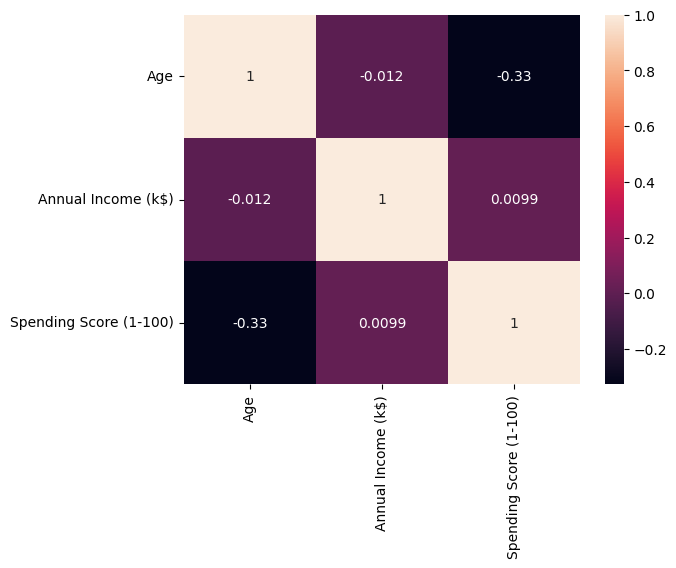

In [ ]:
sns.heatmap(data=df.corr(),annot=True)

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

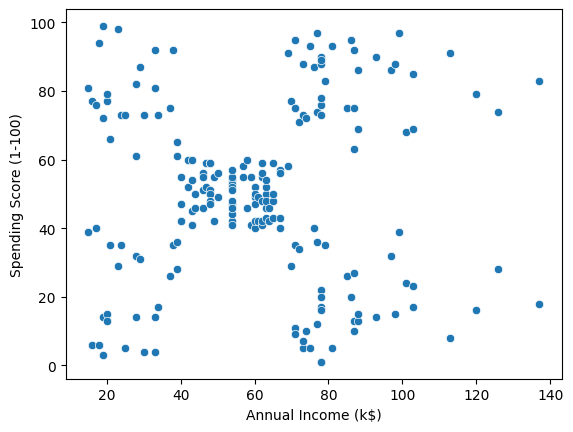

In [ ]:
sns.scatterplot(data=df,x='Annual Income (k$)',y='Spending Score (1-100)')

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [ ]:
x_scaled=scaler.fit_transform(df.drop(['Age'],axis=1))
x_scaled

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992],
       [-1.66266033,  1.00159627],
       [-1.62449091, -1.71591298],
       [-1.62449091,  1.70038436],
       [-1.58632148, -1.83237767],
       [-1.58632148,  0.84631002],
       [-1.58632148, -1.4053405 ],
       [-1.58632148,  1.89449216],
       [-1.54815205, -1.36651894],
       [-1.54815205,  1.04041783],
       [-1.54815205, -1.44416206],
       [-1.54815205,  1.11806095],
       [-1.50998262, -0.59008772],
       [-1.50998262,  0.61338066],
       [-1.43364376, -0.82301709],
       [-1.43364376,  1.8556706 ],
       [-1.39547433, -0.59008772],
       [-1.39547433,  0.88513158],
       [-1.3573049 , -1.75473454],
       [-1.3573049 ,  0.88513158],
       [-1.24279661, -1.4053405 ],
       [-1.24279661,  1.23452563],
       [-1.24279661, -0.7065524 ],
       [-1.24279661,  0.41927286],
       [-1.20462718,

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
wcss=[]
sil_scores=[]
for i in range(2,11):
  kmeans=KMeans(n_clusters=i,random_state=42,init='k-means++',max_iter=300,n_init=10)
  kmeans.fit_predict(x_scaled)
  labels=kmeans.labels_
  wcss.append(kmeans.inertia_)
  sil_h=silhouette_score(x_scaled,labels)
  sil_scores.append(sil_h)

In [ ]:
for i,k in enumerate(range(2,11)):
  print(f'for k={k}, wcss={wcss[i]:.2f} and silhouette score={sil_scores[i]:.2f}')

for k=2, wcss=269.69 and silhouette score=0.32
for k=3, wcss=157.70 and silhouette score=0.47
for k=4, wcss=108.92 and silhouette score=0.49
for k=5, wcss=65.57 and silhouette score=0.55
for k=6, wcss=55.06 and silhouette score=0.54
for k=7, wcss=44.86 and silhouette score=0.53
for k=8, wcss=37.23 and silhouette score=0.46
for k=9, wcss=32.39 and silhouette score=0.46
for k=10, wcss=29.98 and silhouette score=0.44


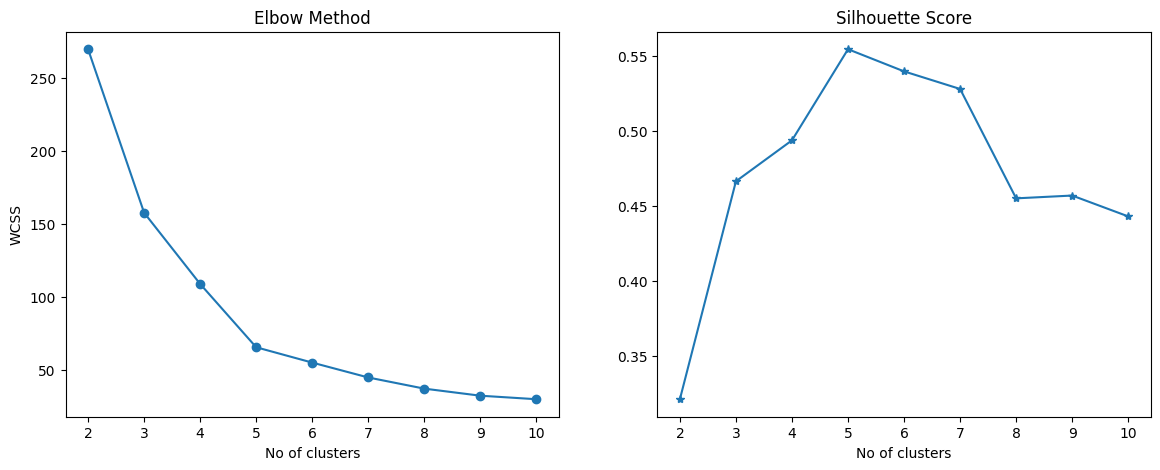

In [ ]:
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(range(2,11),wcss,marker='o')
plt.title('Elbow Method')
plt.xlabel('No of clusters')
plt.ylabel('WCSS')
plt.subplot(1,2,2)
plt.plot(range(2,11),sil_scores,marker='*')
plt.title('Silhouette Score')
plt.xlabel('No of clusters')

plt.show()

In [ ]:
kmeans=KMeans(n_clusters=5,random_state=42,init='k-means++',max_iter=300,n_init=10)
kmeans.fit(x_scaled)
cluster_labels=kmeans.predict(x_scaled)
cluster_labels

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [ ]:
df['kmeans_clusters']=cluster_labels
df.head()

,Age,Annual Income (k$),Spending Score (1-100),kmeans_clusters
0,19,15,39,4
1,21,15,81,2
2,20,16,6,4
3,23,16,77,2
4,31,17,40,4


In [ ]:
df['kmeans_clusters'].value_counts()

,count
kmeans_clusters,
0,81
1,39
3,35
4,23
2,22


<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

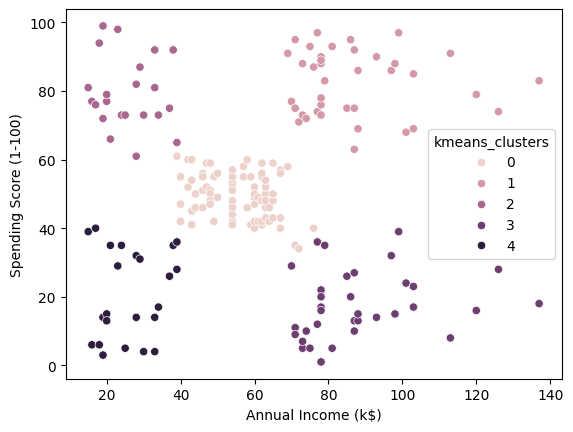

In [ ]:
sns.scatterplot(data=df,x='Annual Income (k$)',y='Spending Score (1-100)',hue='kmeans_clusters')

In [ ]:
new_customer=np.array([[45,60]])
scaled=scaler.transform(new_customer)
cluster=kmeans.predict(scaled)
cluster


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([0], dtype=int32)

In [ ]:
# agglomerative clustering, hierarichical clustering

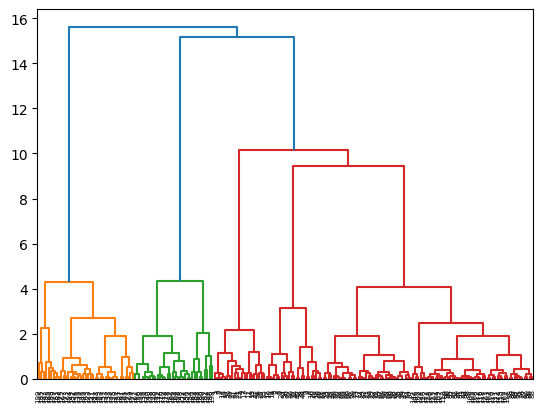

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage

mergings=linkage(x_scaled,method='ward')
dendrogram(mergings)
plt.show()

In [ ]:
from sklearn.cluster import AgglomerativeClustering

agg_hc=AgglomerativeClustering(n_clusters=5,metric='euclidean',linkage='ward')
agg_cluster=agg_hc.fit_predict(x_scaled)
agg_cluster

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 2,
       4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 2, 1, 0, 1, 0, 1,
       2, 1, 0, 1, 0, 1, 0, 1, 0, 1, 2, 1, 0, 1, 2, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 2, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1])

In [ ]:
df['agg_cluster']=agg_cluster
df.head()

,Age,Annual Income (k$),Spending Score (1-100),kmeans_clusters,agg_cluster
0,19,15,39,4,4
1,21,15,81,2,3
2,20,16,6,4,4
3,23,16,77,2,3
4,31,17,40,4,4


In [ ]:
df.kmeans_clusters.value_counts()

,count
kmeans_clusters,
0,81
1,39
3,35
4,23
2,22


In [ ]:
df['agg_cluster'].value_counts()

,count
agg_cluster,
2,85
1,39
0,32
4,23
3,21


<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

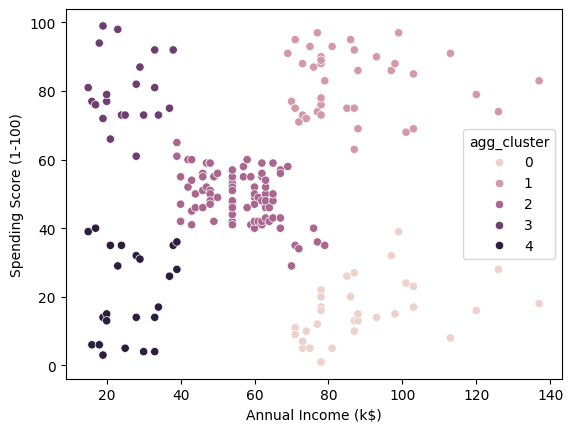

In [ ]:
sns.scatterplot(data=df,x='Annual Income (k$)',y='Spending Score (1-100)',hue='agg_cluster')

In [ ]:
sil_scores={}

for i in range(2,11):
  agg_hc=AgglomerativeClustering(n_clusters=i,metric='euclidean',linkage='ward')
  sil_h=silhouette_score(x_scaled,agg_hc.fit_predict(x_scaled))
  sil_scores[i]=sil_h

sil_scores

{2: np.float64(0.3842337621772661),
 3: np.float64(0.4610481446570447),
 4: np.float64(0.4925507715349343),
 5: np.float64(0.5538089226688662),
 6: np.float64(0.5386761871036926),
 7: np.float64(0.5197949293475768),
 8: np.float64(0.4308617778221774),
 9: np.float64(0.43768997758154127),
 10: np.float64(0.4339007174968657)}

In [ ]:
from scipy.cluster.hierarchy import fcluster

In [ ]:
cluster_labels=fcluster(mergings,t=5,criterion='maxclust')
cluster_labels

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 5,
       4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 1, 5, 1, 5, 1, 2, 1, 2, 1,
       5, 1, 2, 1, 2, 1, 2, 1, 2, 1, 5, 1, 2, 1, 5, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 5, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1], dtype=int32)

In [ ]:
from sklearn.cluster import AgglomerativeClustering

In [ ]:
agg_hc=AgglomerativeClustering(n_clusters=5,metric='euclidean',linkage='ward')
agg_cluster=agg_hc.fit_predict(x_scaled)
agg_cluster0


array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 2,
       4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 2, 1, 0, 1, 0, 1,
       2, 1, 0, 1, 0, 1, 0, 1, 0, 1, 2, 1, 0, 1, 2, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 2, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1])

In [ ]:
from sklearn.cluster import DBSCAN

In [ ]:
dbscan=DBSCAN(eps=0.25,min_samples=5)
dbscan_cluster=dbscan.fit_predict(x_scaled)
dbscan_cluster

array([-1,  0, -1,  0, -1,  0, -1, -1, -1,  0, -1, -1, -1,  0, -1,  0,  1,
        0,  1, -1,  1,  0, -1,  0, -1, -1,  1, -1,  1, -1, -1,  0, -1, -1,
       -1, -1, -1, -1, -1, -1,  2, -1,  2,  2, -1,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  2,  3,  2,  3,  2,  3,  4,  3,  4,  3,  2,  3,  4,  3,
        4,  3,  4,  3,  4,  3,  2,  3,  4,  3,  2,  3,  4,  3,  4,  3,  4,
        3,  4,  3,  4,  3,  4,  3,  2,  3,  4,  3, -1, -1,  5,  3, -1, -1,
        5, -1,  5,  3,  5,  3,  5, -1,  5,  3, -1,  3,  5,  3, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1])

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df1=pd.read_csv('/content/fish.csv')
df1.head()

,Bream,242.0,23.2,25.4,30.0,38.4,13.4
0,Bream,290.0,24.0,26.3,31.2,40.0,13.8
1,Bream,340.0,23.9,26.5,31.1,39.8,15.1
2,Bream,363.0,26.3,29.0,33.5,38.0,13.3
3,Bream,430.0,26.5,29.0,34.0,36.6,15.1
4,Bream,450.0,26.8,29.7,34.7,39.2,14.2


In [ ]:
df1.info()
df1.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Bream   84 non-null     object 
 1   242.0   84 non-null     float64
 2   23.2    84 non-null     float64
 3   25.4    84 non-null     float64
 4   30.0    84 non-null     float64
 5   38.4    84 non-null     float64
 6   13.4    84 non-null     float64
dtypes: float64(6), object(1)
memory usage: 4.7+ KB


,0
Bream,0
242.0,0
23.2,0
25.4,0
30.0,0
38.4,0
13.4,0


In [ ]:
df1['Bream'].value_counts()

,count
Bream,
Bream,33
Roach,20
Pike,17
Smelt,14


In [ ]:
df1

,Bream,242.0,23.2,25.4,30.0,38.4,13.4
0,Bream,290.0,24.0,26.3,31.2,40.0,13.8
1,Bream,340.0,23.9,26.5,31.1,39.8,15.1
2,Bream,363.0,26.3,29.0,33.5,38.0,13.3
3,Bream,430.0,26.5,29.0,34.0,36.6,15.1
4,Bream,450.0,26.8,29.7,34.7,39.2,14.2
...,...,...,...,...,...,...,...
79,Pike,950.0,48.3,51.7,55.1,16.2,11.2
80,Pike,1250.0,52.0,56.0,59.7,17.9,11.7
81,Pike,1600.0,56.0,60.0,64.0,15.0,9.6
82,Pike,1550.0,56.0,60.0,64.0,15.0,9.6


In [ ]:
df1=df1.rename(columns={'242.0':'Weight',
                        '23.2':'Vlength',
                        '25.4':'Dlength',
                        '30.0':'Clength',
                        '38.4':'Height',
                        '13.4':'Width',
                        'Bream':'Species'})


In [ ]:
df1.drop('Species',axis=1,inplace=True)


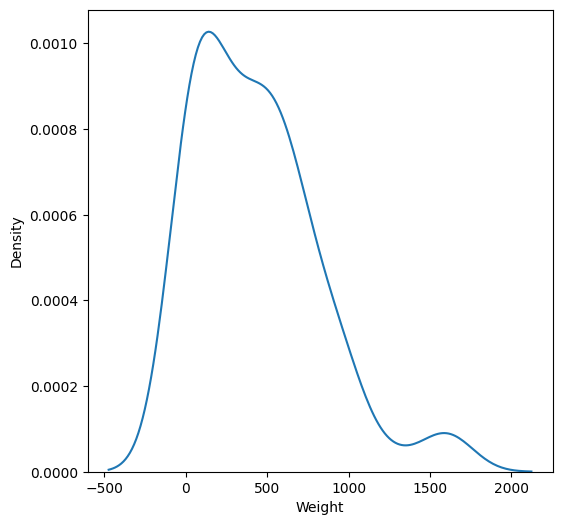

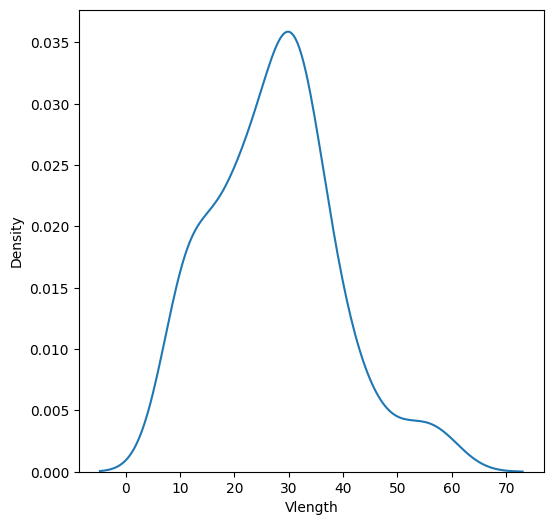

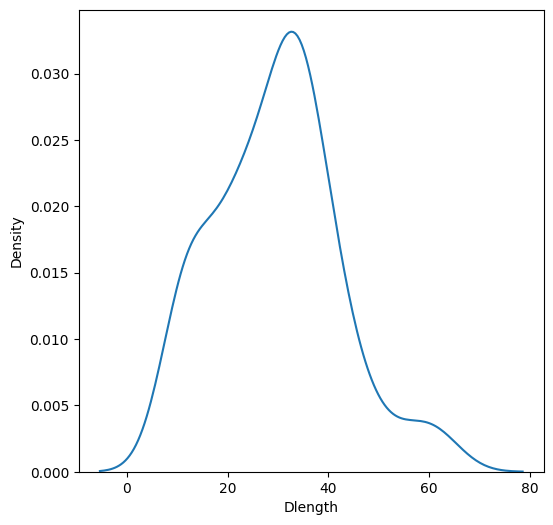

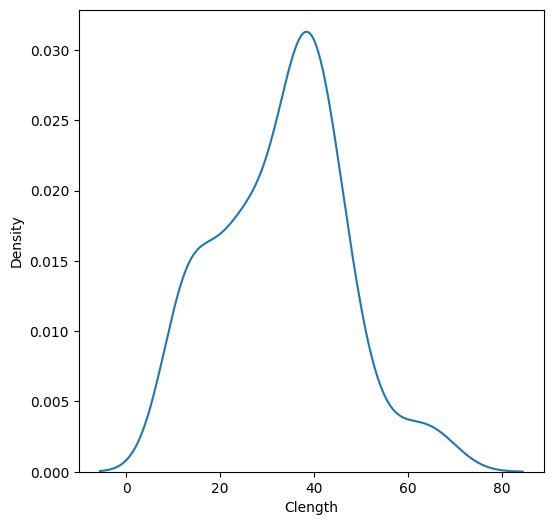

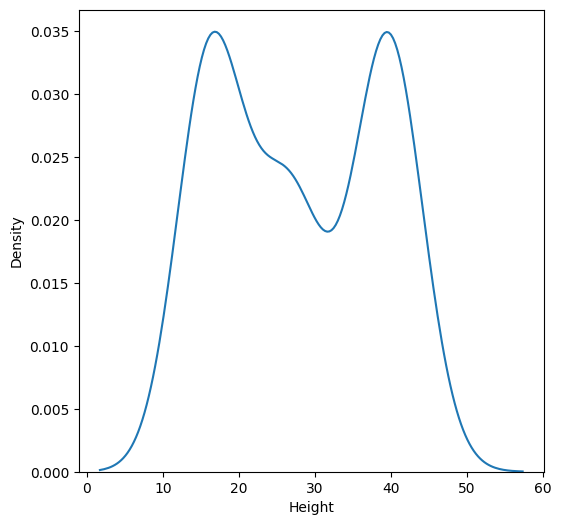

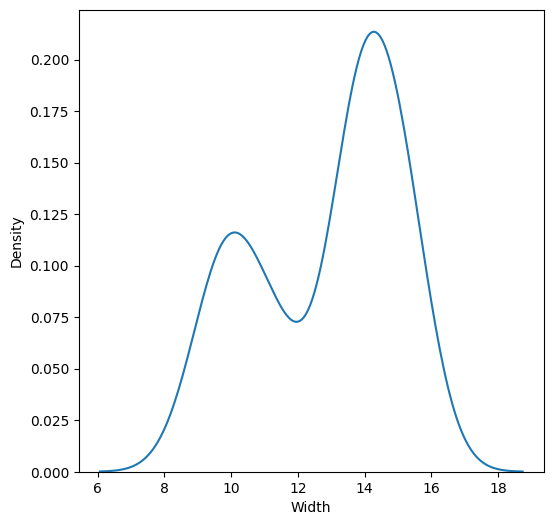

In [ ]:
numerical_col=df1.select_dtypes(include=np.number).columns
for col in numerical_col:
  plt.figure(figsize=(6,6))
  sns.kdeplot(df1[col])
  plt.show()

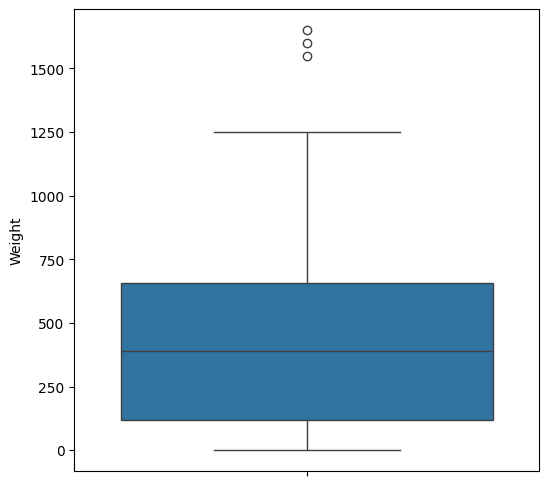

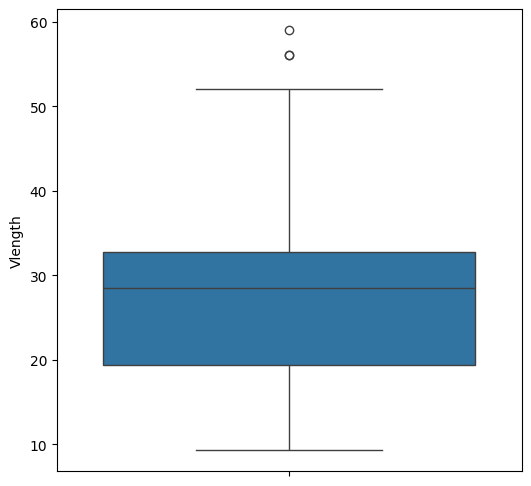

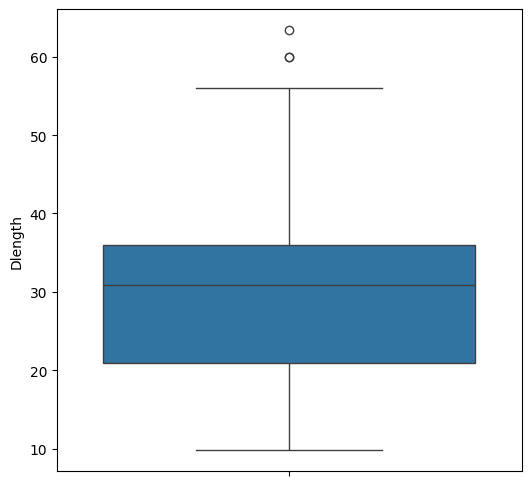

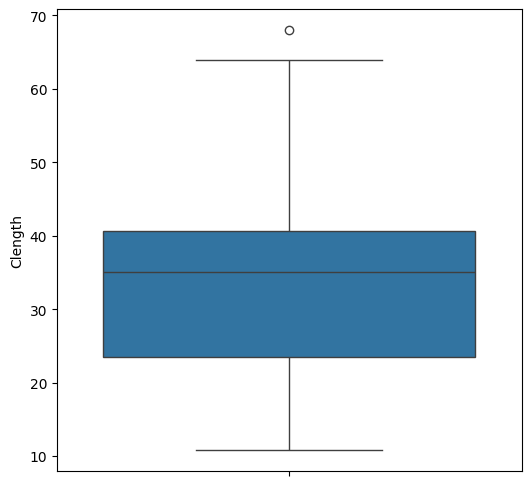

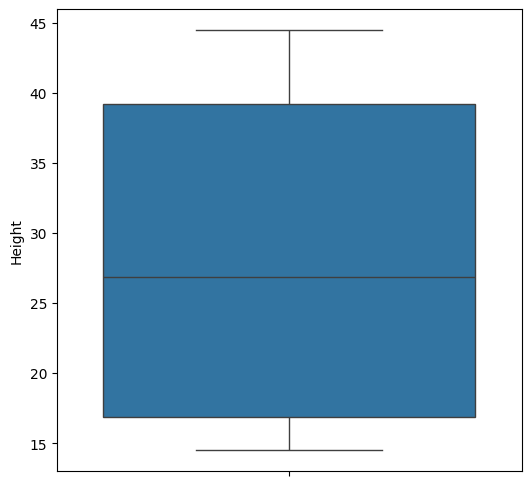

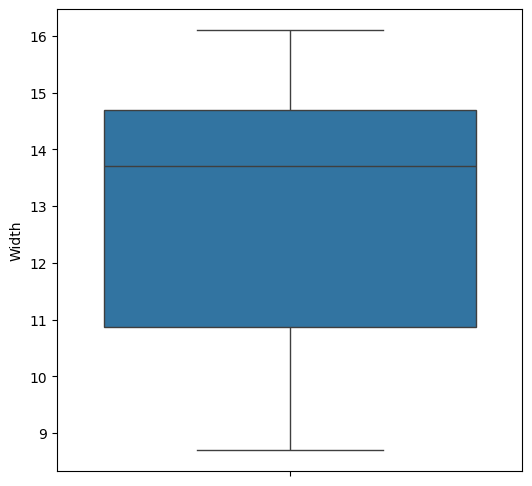

In [ ]:
for col in numerical_col:
  plt.figure(figsize=(6,6))
  sns.boxplot(df1[col])
  plt.show()

In [ ]:
from scipy.stats import skew

In [ ]:
for col in numerical_col:
  skew_value=df1[col].skew()
skew_value

np.float64(-0.4942330151273134)

In [ ]:
numerical_col

Index(['Weight', 'Vlength', 'Dlength', 'Clength', 'Height', 'Width'], dtype='object')

In [ ]:
df1.skew()

,0
Weight,1.093594
Vlength,0.485725
Dlength,0.418112
Clength,0.162470
Height,0.055153
Width,-0.494233


In [ ]:
df1

,Weight,Vlength,Dlength,Clength,Height,Width
0,290.0,24.0,26.3,31.2,40.0,13.8
1,340.0,23.9,26.5,31.1,39.8,15.1
2,363.0,26.3,29.0,33.5,38.0,13.3
3,430.0,26.5,29.0,34.0,36.6,15.1
4,450.0,26.8,29.7,34.7,39.2,14.2
...,...,...,...,...,...,...
79,950.0,48.3,51.7,55.1,16.2,11.2
80,1250.0,52.0,56.0,59.7,17.9,11.7
81,1600.0,56.0,60.0,64.0,15.0,9.6
82,1550.0,56.0,60.0,64.0,15.0,9.6


In [ ]:
df1.corr()

,Weight,Vlength,Dlength,Clength,Height,Width
Weight,1.000000,0.897336,0.903897,0.917724,0.297796,0.077788
Vlength,0.897336,1.000000,0.999505,0.992544,0.088572,-0.041463
Dlength,0.903897,0.999505,1.000000,0.995397,0.114809,-0.019740
Clength,0.917724,0.992544,0.995397,1.000000,0.205021,0.046769
Height,0.297796,0.088572,0.114809,0.205021,1.000000,0.772772
Width,0.077788,-0.041463,-0.019740,0.046769,0.772772,1.000000


<Axes: >

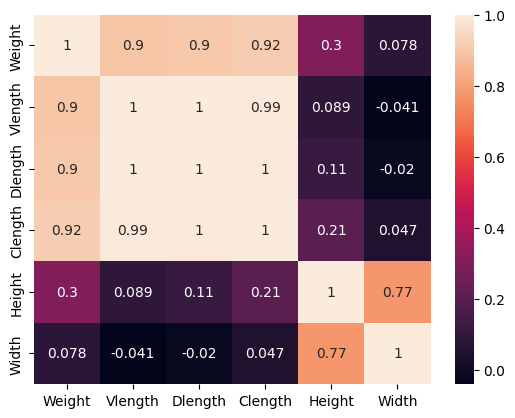

In [ ]:
sns.heatmap(df1.corr(),annot=True)

<Axes: xlabel='Vlength', ylabel='Weight'>

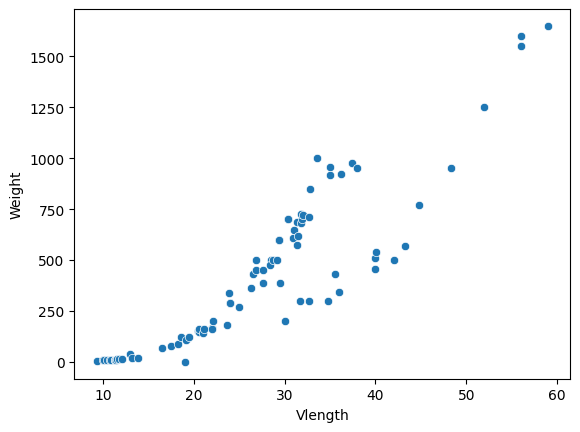

In [ ]:
sns.scatterplot(data=df1,x='Vlength',y='Weight')

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [ ]:
x_scaled=scaler.fit_transform(df1)
x_scaled

array([[-0.37863149, -0.30035487, -0.2716005 , -0.14834877,  1.1707675 ,
         0.44432002],
       [-0.24717853, -0.30921988, -0.25517542, -0.15592863,  1.15132991,
         1.05849403],
       [-0.18671016, -0.09645972, -0.04986186,  0.02598811,  0.97639163,
         0.20809925],
       [-0.01056318, -0.0787297 , -0.04986186,  0.06388743,  0.84032853,
         1.05849403],
       [ 0.042018  , -0.05213468,  0.00762593,  0.11694647,  1.09301715,
         0.63329664],
       [ 0.17347097, -0.05213468,  0.00762593,  0.10178675,  1.27767423,
         1.15298234],
       [-0.11572556,  0.01878537,  0.03226356,  0.13968607,  0.80145335,
         0.25534341],
       [ 0.042018  ,  0.01878537,  0.03226356,  0.14726593,  1.16104871,
         0.44432002],
       [ 0.17347097,  0.09857043,  0.08975135,  0.23064443,  1.10273595,
         0.39707587],
       [ 0.10774449,  0.08970542,  0.11438898,  0.23064443,  1.11245474,
         0.58605249],
       [ 0.17347097,  0.11630044,  0.11438898,  0.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
wcss=[]
sil_scores=[]
for i in range(2,11):
  kmeans=KMeans(n_clusters=i,random_state=42,init='k-means++',max_iter=300,n_init=10)
  kmeans.fit_predict(x_scaled)
  labels=kmeans.labels_
  wcss.append(kmeans.inertia_)
  sil_h=silhouette_score(x_scaled,labels)
  sil_scores.append(sil_h)

In [ ]:
for i,k in enumerate(range(2,11)):
  print(f'for k={k}, wcss={wcss[i]:.2f} and silhouette score={sil_scores[i]:.2f}')

for k=2, wcss=280.89 and silhouette score=0.42
for k=3, wcss=152.52 and silhouette score=0.52
for k=4, wcss=95.64 and silhouette score=0.57
for k=5, wcss=50.03 and silhouette score=0.61
for k=6, wcss=37.64 and silhouette score=0.53
for k=7, wcss=31.31 and silhouette score=0.51
for k=8, wcss=26.62 and silhouette score=0.50
for k=9, wcss=22.88 and silhouette score=0.45
for k=10, wcss=19.87 and silhouette score=0.45


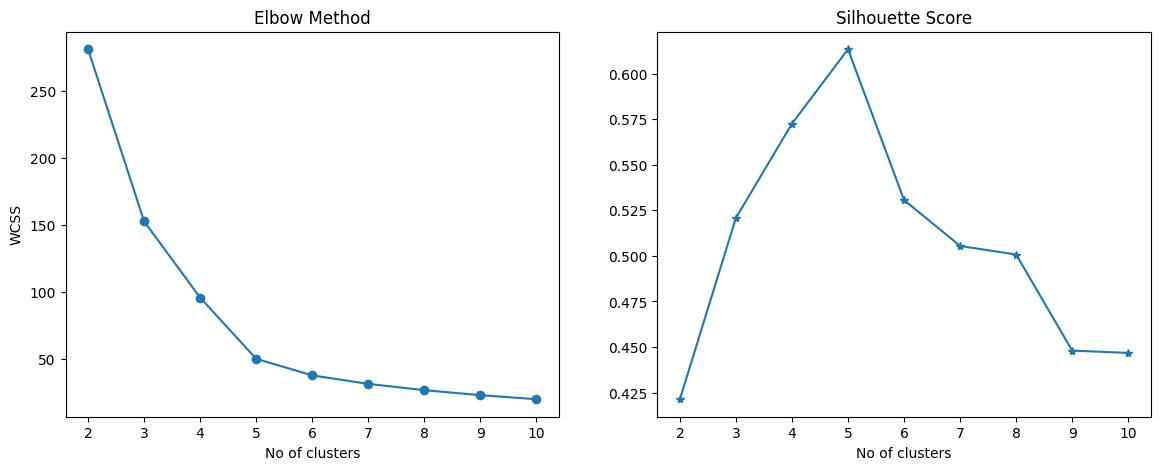

In [ ]:
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(range(2,11),wcss,marker='o')
plt.title('Elbow Method')
plt.xlabel('No of clusters')
plt.ylabel('WCSS')
plt.subplot(1,2,2)
plt.plot(range(2,11),sil_scores,marker='*')
plt.title('Silhouette Score')
plt.xlabel('No of clusters')

plt.show()

In [ ]:
kmeans=KMeans(n_clusters=5,random_state=42,init='k-means++',max_iter=300,n_init=10)
kmeans.fit(x_scaled)
cluster_labels=kmeans.predict(x_scaled)
cluster_labels

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1,
       3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 4, 4, 4, 4], dtype=int32)

In [ ]:
df1['kmeans_clusters']=cluster_labels
df1.head()

,Weight,Vlength,Dlength,Clength,Height,Width,kmeans_clusters
0,290.0,24.0,26.3,31.2,40.0,13.8,0
1,340.0,23.9,26.5,31.1,39.8,15.1,0
2,363.0,26.3,29.0,33.5,38.0,13.3,0
3,430.0,26.5,29.0,34.0,36.6,15.1,0
4,450.0,26.8,29.7,34.7,39.2,14.2,0


In [ ]:
df1['kmeans_clusters'].value_counts()

,count
kmeans_clusters,
0,34
1,20
3,13
2,12
4,5


<Axes: xlabel='Vlength', ylabel='Weight'>

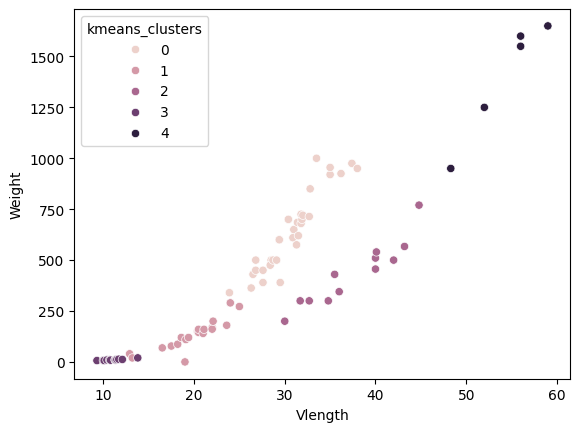

In [ ]:
sns.scatterplot(data=df1,x='Vlength',y='Weight',hue='kmeans_clusters')

In [ ]:
new_fish=np.array([[20,300,20,20,20,20]])
scaled=scaler.transform(new_fish)
cluster=kmeans.predict(scaled)
cluster

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([4], dtype=int32)

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Weight           84 non-null     float64
 1   Vlength          84 non-null     float64
 2   Dlength          84 non-null     float64
 3   Clength          84 non-null     float64
 4   Height           84 non-null     float64
 5   Width            84 non-null     float64
 6   kmeans_clusters  84 non-null     int32  
dtypes: float64(6), int32(1)
memory usage: 4.4 KB


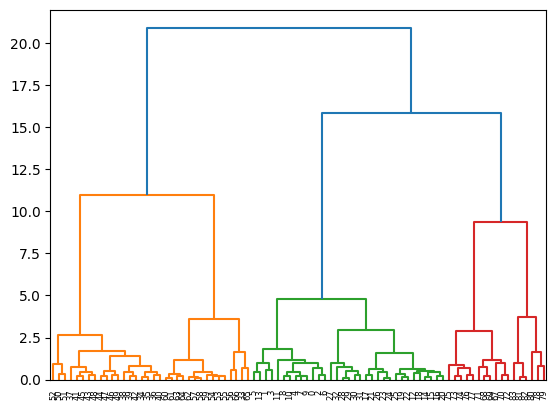

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage

mergings=linkage(x_scaled,method='ward')
dendrogram(mergings)
plt.show()

In [ ]:
from sklearn.cluster import AgglomerativeClustering

agg_hc=AgglomerativeClustering(n_clusters=5,metric='euclidean',linkage='ward')
agg_cluster=agg_hc.fit_predict(x_scaled)
agg_cluster

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 2, 2, 2, 2, 2, 2])

In [ ]:
df['agg_cluster']=agg_cluster
df.head()

ValueError: Length of values (84) does not match length of index (200)

In [ ]:
df.kmeans_clusters.value_counts()

,count
kmeans_clusters,
0,81
1,39
3,35
4,23
2,22


In [ ]:
df['agg_cluster'].value_counts()

,count
agg_cluster,
2,85
1,39
0,32
4,23
3,21


<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

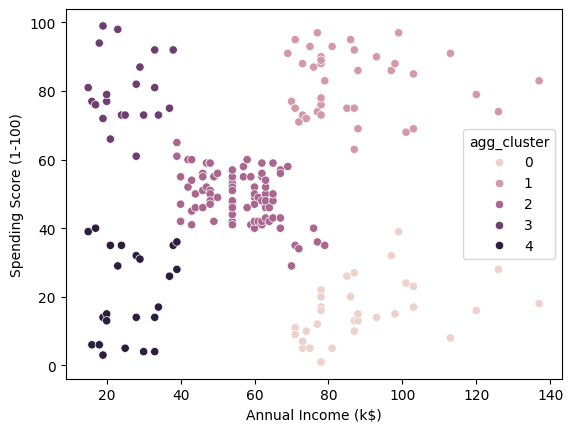

In [ ]:
sns.scatterplot(data=df,x='Annual Income (k$)',y='Spending Score (1-100)',hue='agg_cluster')

array([3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5], dtype=int32)